In [39]:
!pip install -q tensorflow matplotlib pandas scikit-learn pillow

In [40]:

import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image
from sklearn.model_selection import train_test_split

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [41]:
!git clone https://github.com/cosmos-sajal/Face-Recognition.git

fatal: destination path 'Face-Recognition' already exists and is not an empty directory.


In [42]:
DATASET_DIR = "/content/Face-Recognition/yalefaces/yalefaces"

In [43]:
print("Dataset directory:", DATASET_DIR)
print(os.listdir(DATASET_DIR))

Dataset directory: /content/Face-Recognition/yalefaces/yalefaces
['subject15.sleepy.gif', 'subject11.sleepy.gif', 'subject12.normal.gif', 'subject09.wink.gif', 'subject08.normal.gif', 'subject15.surprised.gif', 'subject07.wink.gif', 'subject15.sad.gif', 'subject14.sad.gif', 'subject06.normal.gif', 'subject06.centerlight.gif', 'subject07.leftlight.gif', 'subject15.glasses.gif', 'subject12.happy.gif', 'subject01.noglasses.gif', 'subject11.sad.gif', 'subject03.noglasses.gif', 'subject05.centerlight.gif', 'subject02.centerlight.gif', 'subject07.centerlight.gif', 'subject14.wink.gif', 'subject10.wink.gif', 'subject09.happy.gif', 'subject10.sleepy.gif', 'subject09.centerlight.gif', 'subject09.sleepy.gif', 'subject14.leftlight.gif', 'subject02.glasses.gif', 'subject04.centerlight.gif', 'subject13.leftlight.gif', 'subject01.gif', 'subject06.wink.gif', 'subject12.wink.gif', 'subject13.rightlight.gif', 'subject02.leftlight.gif', 'subject06.happy.gif', 'subject12.surprised.gif', 'subject03.normal

In [44]:
subject_ids = set()

for filename in os.listdir(DATASET_DIR):

    if filename.lower().endswith(".gif"):

        match = re.match(
            r"subject(\d+)\.",
            filename
        )

        if match:
            subject_ids.add(
                int(match.group(1))
            )

subject_ids = sorted(subject_ids)

NUM_CLASSES = len(subject_ids)

class_names = [
    f"subject{i:02d}"
    for i in subject_ids
]

print("Number of classes:", NUM_CLASSES)

print("\nClasses:")

for i, name in enumerate(class_names):
    print(i, "->", name)

Number of classes: 15

Classes:
0 -> subject01
1 -> subject02
2 -> subject03
3 -> subject04
4 -> subject05
5 -> subject06
6 -> subject07
7 -> subject08
8 -> subject09
9 -> subject10
10 -> subject11
11 -> subject12
12 -> subject13
13 -> subject14
14 -> subject15


In [45]:
subject_ids = set()

for filename in os.listdir(DATASET_DIR):

    if filename.lower().endswith(".gif"):

        match = re.match(
            r"subject(\d+)\.",
            filename
        )

        if match:
            subject_ids.add(
                int(match.group(1))
            )

subject_ids = sorted(subject_ids)

NUM_CLASSES = len(subject_ids)

class_names = [
    f"subject{i:02d}"
    for i in subject_ids
]

print("Number of classes:", NUM_CLASSES)

print("\nClasses:")

for i, name in enumerate(class_names):
    print(i, "->", name)

Number of classes: 15

Classes:
0 -> subject01
1 -> subject02
2 -> subject03
3 -> subject04
4 -> subject05
5 -> subject06
6 -> subject07
7 -> subject08
8 -> subject09
9 -> subject10
10 -> subject11
11 -> subject12
12 -> subject13
13 -> subject14
14 -> subject15


In [46]:
subject_to_class = {
    subject_id: index
    for index, subject_id in enumerate(subject_ids)
}

print(subject_to_class)

{1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7, 9: 8, 10: 9, 11: 10, 12: 11, 13: 12, 14: 13, 15: 14}


In [47]:
image_paths = []
labels = []

for filename in sorted(os.listdir(DATASET_DIR)):

    if filename.lower().endswith(".gif"):

        match = re.match(
            r"subject(\d+)\.",
            filename
        )

        if match:

            subject_id = int(
                match.group(1)
            )

            label = subject_to_class[
                subject_id
            ]

            image_path = os.path.join(
                DATASET_DIR,
                filename
            )

            image_paths.append(
                image_path
            )

            labels.append(
                label
            )

print("Total images:", len(image_paths))
print("Total labels:", len(labels))

Total images: 165
Total labels: 165


In [48]:
unique_labels, counts = np.unique(
    labels,
    return_counts=True
)

print("\nImages per subject:\n")

for label, count in zip(
    unique_labels,
    counts
):

    print(
        f"{class_names[label]} : {count} images"
    )


Images per subject:

subject01 : 11 images
subject02 : 11 images
subject03 : 11 images
subject04 : 11 images
subject05 : 11 images
subject06 : 11 images
subject07 : 11 images
subject08 : 11 images
subject09 : 11 images
subject10 : 11 images
subject11 : 11 images
subject12 : 11 images
subject13 : 11 images
subject14 : 11 images
subject15 : 11 images


In [49]:
# IMG_SIZE = 64

# X = []
# y = []

# for image_path, label in zip(
#     image_paths,
#     labels
# ):

#     try:

#         image = Image.open(
#             image_path
#         ).convert("RGB")

#         image = image.resize(
#             (IMG_SIZE, IMG_SIZE)
#         )

#         image = np.asarray(
#             image,
#             dtype=np.float32
#         )

#         X.append(image)
#         y.append(label)

#     except Exception as e:

#         print(
#             "Error loading:",
#             image_path
#         )

#         print(e)

# X = np.array(X, dtype=np.float32)
# y = np.array(y, dtype=np.int32)

# print("\nX shape:", X.shape)
# print("y shape:", y.shape)

IMG_SIZE = 64

X = []
y = []

for image_path, label in zip(
    image_paths,
    labels
):

    try:

        # Load as grayscale
        image = Image.open(
            image_path
        ).convert("L")

        # Resize
        image = image.resize(
            (IMG_SIZE, IMG_SIZE)
        )

        # Convert to numpy
        image = np.asarray(
            image,
            dtype=np.float32
        )

        X.append(image)
        y.append(label)

    except Exception as e:

        print(
            "Error loading:",
            image_path
        )

        print(e)

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.int32
)

print("Before normalization:")
print("X shape:", X.shape)
print("y shape:", y.shape)

Before normalization:
X shape: (165, 64, 64)
y shape: (165,)


In [50]:
# X = X / 255.0

# print("Minimum pixel value:", X.min())
# print("Maximum pixel value:", X.max())
X = X[..., np.newaxis]

print("X shape:", X.shape)

X shape: (165, 64, 64, 1)


In [51]:
X = X / 255.0

print("Minimum:", X.min())
print("Maximum:", X.max())

Minimum: 0.0
Maximum: 1.0


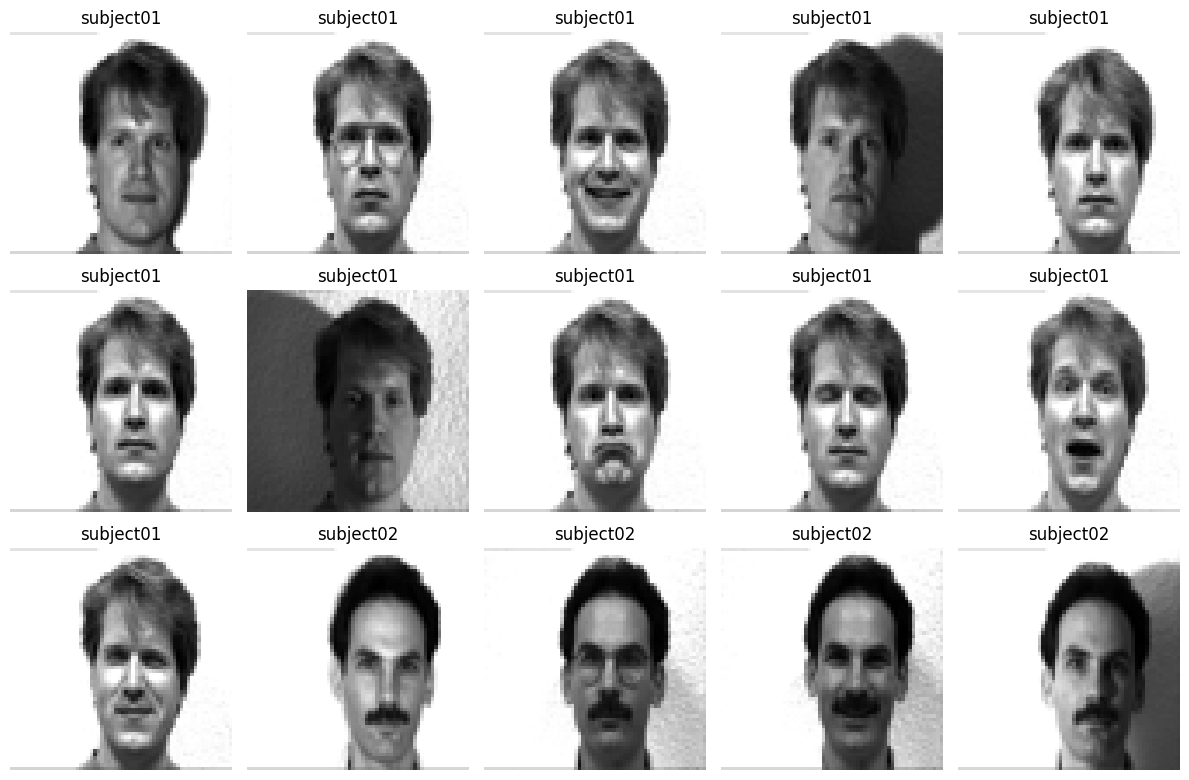

In [52]:
plt.figure(figsize=(12, 8))

num_samples = min(
    15,
    len(X)
)

for i in range(num_samples):

    plt.subplot(3, 5, i + 1)

    plt.imshow(
        X[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        class_names[y[i]]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (132, 64, 64, 1)
X_test : (33, 64, 64, 1)


In [54]:
def build_face_model():

    model = tf.keras.Sequential([

        tf.keras.layers.Input(
            shape=(IMG_SIZE, IMG_SIZE, 1)
        ),

        tf.keras.layers.Conv2D(
            32,
            3,
            activation="relu",
            padding="same"
        ),

        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(
            64,
            3,
            activation="relu",
            padding="same"
        ),

        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(
            128,
            3,
            activation="relu",
            padding="same"
        ),

        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(
            128,
            activation="relu"
        ),

        tf.keras.layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    ])

    return model

In [55]:
model = build_face_model()

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,311 (4.36 MB)

 Trainable params: 1,143,311 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [56]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 237ms/step - accuracy: 0.0762 - loss: 2.7815 - val_accuracy: 0.0370 - val_loss: 2.7205
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - accuracy: 0.1333 - loss: 2.6813 - val_accuracy: 0.0741 - val_loss: 2.7423
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 0.2857 - loss: 2.5741 - val_accuracy: 0.1481 - val_loss: 2.7310
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.4476 - loss: 2.2395 - val_accuracy: 0.1852 - val_loss: 2.5199
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.5619 - loss: 1.7056 - val_accuracy: 0.3333 - val_loss: 1.8202
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 0.7524 - loss: 0.9814 - val_accuracy: 0.7037 - val_loss: 1.0198
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 0.8190 - loss: 0.6022 - val_accuracy: 0.7778 - val_loss: 0.7875
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.9048 - loss: 0.3492 - val_accuracy: 0.7778 - val_loss:

In [57]:
test_loss, test_acc = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(
    "Test accuracy:",
    test_acc
)

Test accuracy: 0.9090909361839294


In [58]:
target_class = 0

idx = np.where(
    y_test == target_class
)[0][0]

real_image = X_test[
    idx:idx+1
]

prediction = model.predict(
    real_image,
    verbose=0
)

print(
    "Real subject:",
    class_names[target_class]
)

print(
    "Target confidence:",
    prediction[0][target_class]
)

print(
    "Predicted subject:",
    class_names[
        np.argmax(prediction[0])
    ]
)

Real subject: subject01
Target confidence: 0.99998546
Predicted subject: subject01


In [59]:
random_image = tf.random.uniform(
    shape=(
        1,
        IMG_SIZE,
        IMG_SIZE,
        1
    ),
    minval=0.0,
    maxval=1.0
)

random_prediction = model.predict(
    random_image,
    verbose=0
)

print(
    "Random image target confidence:",
    random_prediction[0][target_class]
)

print(
    "Random predicted subject:",
    class_names[
        np.argmax(random_prediction[0])
    ]
)

Random image target confidence: 0.0048025716
Random predicted subject: subject06


In [60]:
def total_variation_loss(x):

    horizontal = x[:, :, 1:, :] - x[:, :, :-1, :]
    vertical = x[:, 1:, :, :] - x[:, :-1, :, :]

    return (
        tf.reduce_mean(
            tf.abs(horizontal)
        )
        +
        tf.reduce_mean(
            tf.abs(vertical)
        )
    )

### NOW MODEL INVERSION

In [61]:
def model_inversion_attack(
    model,
    target_class,
    img_size=64,
    max_iter=2000,
    learning_rate=0.005,
    threshold=0.99,
    tv_weight=0.001
):

    # Random GRAYSCALE image
    x = tf.Variable(
        tf.random.uniform(
            shape=(
                1,
                img_size,
                img_size,
                1
            ),
            minval=0.0,
            maxval=1.0
        ),
        trainable=True
    )

    history = []

    for iteration in range(max_iter):

        with tf.GradientTape() as tape:

            predictions = model(
                x,
                training=False
            )

            target_probability = predictions[
                0,
                target_class
            ]

            # Classification objective
            classification_loss = -tf.math.log(
                target_probability + 1e-8
            )

            # Smoothness prior
            tv_loss = total_variation_loss(x)

            # Combined objective
            loss = (
                classification_loss
                +
                tv_weight * tv_loss
            )

        gradients = tape.gradient(
            loss,
            x
        )

        # Normalize gradient
        gradient_norm = tf.sqrt(
            tf.reduce_mean(
                tf.square(gradients)
            )
        ) + 1e-8

        gradients = (
            gradients / gradient_norm
        )

        # Update image
        x.assign_sub(
            learning_rate * gradients
        )

        # Keep pixels valid
        x.assign(
            tf.clip_by_value(
                x,
                0.0,
                1.0
            )
        )

        # Check updated confidence
        updated_prediction = model(
            x,
            training=False
        )

        confidence = float(
            updated_prediction[
                0,
                target_class
            ].numpy()
        )

        history.append(
            confidence
        )

        if iteration % 100 == 0:

            print(
                f"Iteration {iteration:4d} | "
                f"Target: {class_names[target_class]} | "
                f"Confidence: {confidence:.6f}"
            )

        if confidence >= threshold:

            # Don't immediately accept iteration 0.
            # Require some optimization steps.
            if iteration >= 10:

                print(
                    f"\nAttack converged at "
                    f"iteration {iteration}"
                )

                break

    final_prediction = model(
        x,
        training=False
    )

    final_confidence = float(
        final_prediction[
            0,
            target_class
        ].numpy()
    )

    predicted_class = int(
        tf.argmax(
            final_prediction[0]
        ).numpy()
    )

    return (
        x.numpy(),
        final_confidence,
        predicted_class,
        history
    )

Test one subject

In [62]:
target_class = 0

reconstructed_face, confidence, predicted_class, history = \
    model_inversion_attack(
        model=model,
        target_class=target_class,
        img_size=IMG_SIZE,
        max_iter=2000,
        learning_rate=0.05,
        threshold=0.99,
        tv_weight=0.001
    )

Iteration    0 | Target: subject01 | Confidence: 0.591375

Attack converged at iteration 10


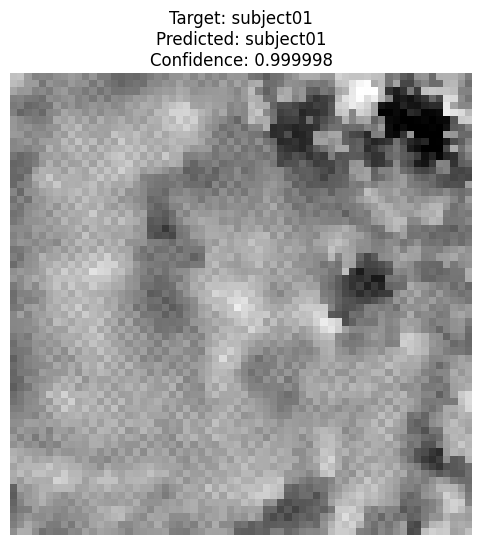

In [63]:
plt.figure(figsize=(6, 6))

plt.imshow(
    reconstructed_face[0].squeeze(),
    cmap="gray"
)

plt.title(
    f"Target: {class_names[target_class]}\n"
    f"Predicted: {class_names[predicted_class]}\n"
    f"Confidence: {confidence:.6f}"
)

plt.axis("off")

plt.show()

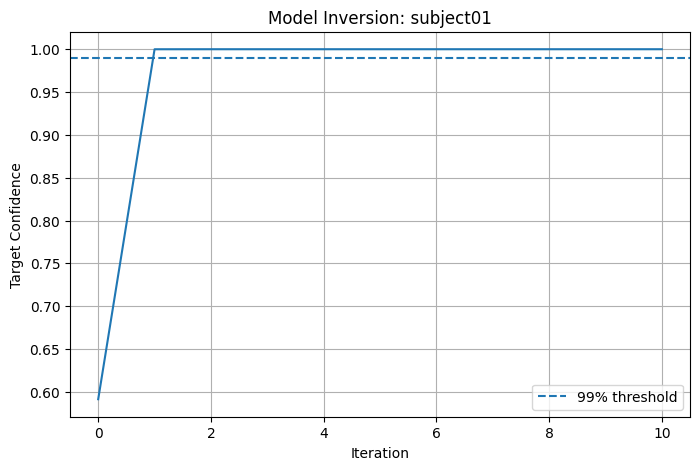

In [64]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(len(history)),
    history
)

plt.axhline(
    0.99,
    linestyle="--",
    label="99% threshold"
)

plt.xlabel("Iteration")
plt.ylabel("Target Confidence")

plt.title(
    f"Model Inversion: "
    f"{class_names[target_class]}"
)

plt.legend()
plt.grid()

plt.show()

## Membership Inference Attack

In [65]:
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [66]:
train_predictions = model.predict(
    X_train,
    verbose=0
)

test_predictions = model.predict(
    X_test,
    verbose=0
)

print("Training predictions:", train_predictions.shape)
print("Testing predictions :", test_predictions.shape)

Training predictions: (132, 15)
Testing predictions : (33, 15)


In [67]:
train_true_confidence = train_predictions[
    np.arange(len(y_train)),
    y_train
]

test_true_confidence = test_predictions[
    np.arange(len(y_test)),
    y_test
]

print(
    "Training confidence:"
)

print(train_true_confidence)

print(
    "\nTesting confidence:"
)

print(test_true_confidence)

Training confidence:
[0.99999005 0.99896765 0.99976563 0.99999994 0.9976907  0.99970055
 0.99999744 0.999999   0.99999243 0.999676   0.99999887 0.99999994
 0.99996084 0.99990135 0.9999135  0.99999243 0.9979583  0.99999994
 0.9999283  0.99981976 0.9997747  0.9998367  0.99999994 0.99997085
 0.99999994 0.99999684 0.99881893 0.99972224 0.99999994 0.9982269
 0.99999994 0.9999626  0.99999696 0.99999994 0.999976   0.9999861
 0.9997747  0.9997592  0.9994728  0.9999667  0.9999859  0.99999994
 0.9999992  0.9999961  0.9998923  0.99982667 0.9999241  0.99901396
 0.9999288  0.99997085 0.9999568  0.9998715  0.9999309  0.99998254
 0.9998777  0.9999698  0.9995013  0.99978924 0.99963075 0.99966097
 0.99990684 0.9999954  0.9999717  0.99978924 0.99970496 0.99999815
 0.99983716 0.99989814 0.999994   0.9999569  0.9999878  0.996495
 0.9999586  0.9999103  0.99988717 0.9999667  0.99999994 0.99992555
 0.9999735  0.9999967  0.9999954  0.99988717 0.99999994 0.99894124
 0.9999606  0.99999803 0.99992615 0.9999829  

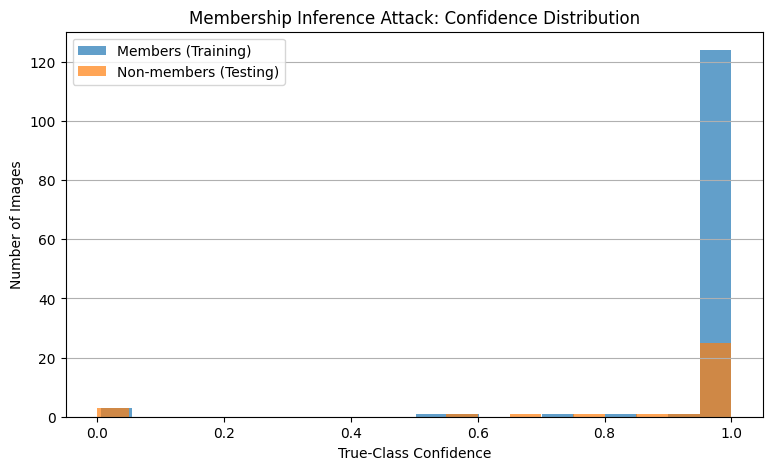

In [68]:
plt.figure(figsize=(9, 5))

plt.hist(
    train_true_confidence,
    bins=20,
    alpha=0.7,
    label="Members (Training)"
)

plt.hist(
    test_true_confidence,
    bins=20,
    alpha=0.7,
    label="Non-members (Testing)"
)

plt.xlabel(
    "True-Class Confidence"
)

plt.ylabel(
    "Number of Images"
)

plt.title(
    "Membership Inference Attack: "
    "Confidence Distribution"
)

plt.legend()

plt.grid(
    axis="y"
)

plt.show()

In [69]:
print(
    "Average member confidence:",
    np.mean(train_true_confidence)
)

print(
    "Average non-member confidence:",
    np.mean(test_true_confidence)
)

Average member confidence: 0.9664585
Average non-member confidence: 0.87449884


In [70]:
confidence_gap = (
    np.mean(train_true_confidence)
    -
    np.mean(test_true_confidence)
)

print(
    "Confidence gap:",
    confidence_gap
)

Confidence gap: 0.091959655


In [71]:
train_loss = -np.log(
    train_true_confidence + 1e-8
)

test_loss = -np.log(
    test_true_confidence + 1e-8
)

print(
    "Average member loss:",
    np.mean(train_loss)
)

print(
    "Average non-member loss:",
    np.mean(test_loss)
)

Average member loss: 0.11314692
Average non-member loss: 0.58580726


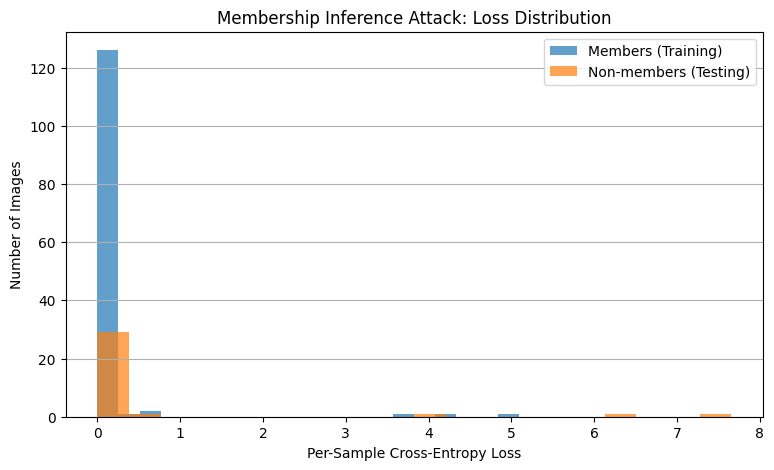

In [72]:
plt.figure(figsize=(9, 5))

plt.hist(
    train_loss,
    bins=20,
    alpha=0.7,
    label="Members (Training)"
)

plt.hist(
    test_loss,
    bins=20,
    alpha=0.7,
    label="Non-members (Testing)"
)

plt.xlabel(
    "Per-Sample Cross-Entropy Loss"
)

plt.ylabel(
    "Number of Images"
)

plt.title(
    "Membership Inference Attack: "
    "Loss Distribution"
)

plt.legend()

plt.grid(
    axis="y"
)

plt.show()

In [73]:
member_scores = train_true_confidence
nonmember_scores = test_true_confidence

membership_scores = np.concatenate([
    member_scores,
    nonmember_scores
])

membership_labels = np.concatenate([
    np.ones(len(member_scores)),
    np.zeros(len(nonmember_scores))
])

print(
    "Total samples:",
    len(membership_labels)
)

print(
    "Members:",
    np.sum(membership_labels == 1)
)

print(
    "Non-members:",
    np.sum(membership_labels == 0)
)

Total samples: 165
Members: 132
Non-members: 33


In [74]:
mia_auc = roc_auc_score(
    membership_labels,
    membership_scores
)

print(
    f"Membership Inference ROC-AUC: "
    f"{mia_auc:.4f}"
)

Membership Inference ROC-AUC: 0.6593


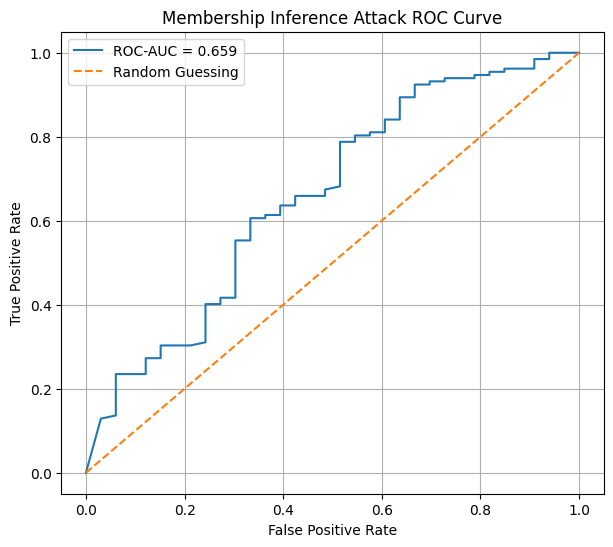

In [75]:
fpr, tpr, thresholds = roc_curve(
    membership_labels,
    membership_scores
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {mia_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guessing"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Membership Inference Attack ROC Curve"
)

plt.legend()

plt.grid()

plt.show()

In [76]:
j_scores = (
    tpr - fpr
)

best_index = np.argmax(
    j_scores
)

best_threshold = thresholds[
    best_index
]

print(
    "Best membership threshold:",
    best_threshold
)

print(
    "TPR:",
    tpr[best_index]
)

print(
    "FPR:",
    fpr[best_index]
)

Best membership threshold: 0.9999004
TPR: 0.6060606060606061
FPR: 0.3333333333333333


In [77]:
predicted_membership = (
    membership_scores
    >= best_threshold
).astype(int)

In [78]:
mia_accuracy = accuracy_score(
    membership_labels,
    predicted_membership
)

print(
    f"Membership inference accuracy: "
    f"{mia_accuracy:.4f}"
)

Membership inference accuracy: 0.6182


In [79]:
cm = confusion_matrix(
    membership_labels,
    predicted_membership
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[22 11]
 [52 80]]


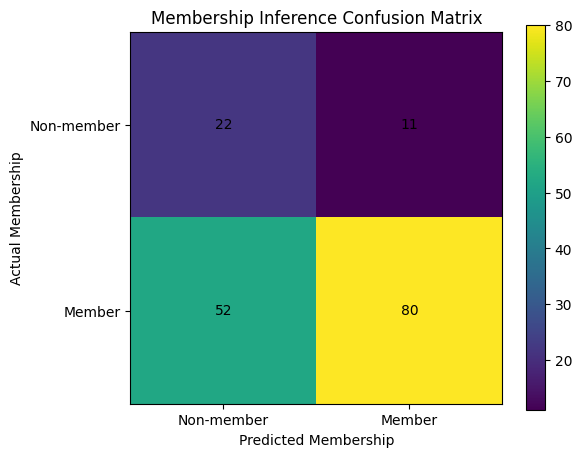

In [80]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title(
    "Membership Inference Confusion Matrix"
)

plt.xlabel(
    "Predicted Membership"
)

plt.ylabel(
    "Actual Membership"
)

plt.xticks(
    [0, 1],
    ["Non-member", "Member"]
)

plt.yticks(
    [0, 1],
    ["Non-member", "Member"]
)

for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()

In [81]:
mia_results = pd.DataFrame({

    "Actual Membership": [
        "Member"
        if x == 1
        else "Non-member"
        for x in membership_labels
    ],

    "True Class": [
        class_names[i]
        for i in np.concatenate([
            y_train,
            y_test
        ])
    ],

    "True-Class Confidence":
        membership_scores,

    "Predicted Membership": [
        "Member"
        if x == 1
        else "Non-member"
        for x in predicted_membership
    ]
})

mia_results.head(20)

,Actual Membership,True Class,True-Class Confidence,Predicted Membership
0,Member,subject04,0.999990,Member
1,Member,subject12,0.998968,Non-member
2,Member,subject03,0.999766,Non-member
3,Member,subject06,1.000000,Member
4,Member,subject12,0.997691,Non-member
5,Member,subject02,0.999701,Non-member
6,Member,subject02,0.999997,Member
7,Member,subject02,0.999999,Member
8,Member,subject05,0.999992,Member
9,Member,subject04,0.999676,Non-member


In [82]:
member_results = mia_results[
    mia_results["Actual Membership"]
    == "Member"
]

nonmember_results = mia_results[
    mia_results["Actual Membership"]
    == "Non-member"
]

print(
    "Average member confidence:",
    member_results[
        "True-Class Confidence"
    ].mean()
)

print(
    "Average non-member confidence:",
    nonmember_results[
        "True-Class Confidence"
    ].mean()
)

Average member confidence: 0.9664585
Average non-member confidence: 0.87449884


In [83]:
subject_member_confidence = []

subject_nonmember_confidence = []

for subject in range(NUM_CLASSES):

    member_idx = np.where(
        y_train == subject
    )[0]

    nonmember_idx = np.where(
        y_test == subject
    )[0]

    subject_member_confidence.append(
        np.mean(
            train_true_confidence[
                member_idx
            ]
        )
    )

    subject_nonmember_confidence.append(
        np.mean(
            test_true_confidence[
                nonmember_idx
            ]
        )
    )

In [85]:
print("=" * 60)
print("MEMBERSHIP INFERENCE ATTACK RESULTS")
print("=" * 60)

print(
    f"Number of members      : {len(X_train)}"
)

print(
    f"Number of non-members  : {len(X_test)}"
)

print(
    f"Average member confidence     : "
    f"{np.mean(train_true_confidence):.6f}"
)

print(
    f"Average non-member confidence : "
    f"{np.mean(test_true_confidence):.6f}"
)

print(
    f"Confidence gap          : "
    f"{confidence_gap:.6f}"
)

print(
    f"Membership ROC-AUC      : "
    f"{mia_auc:.4f}"
)

print(
    f"Membership attack accuracy : "
    f"{mia_accuracy:.4f}"
)

print("=" * 60)

MEMBERSHIP INFERENCE ATTACK RESULTS
Number of members      : 132
Number of non-members  : 33
Average member confidence     : 0.966458
Average non-member confidence : 0.874499
Confidence gap          : 0.091960
Membership ROC-AUC      : 0.6593
Membership attack accuracy : 0.6182
